# HR Analytics Dashboard

This project analyzes employee data to understand workforce patterns, employee attrition, and factors associated with employee turnover.

The analysis includes data cleaning, HR metrics, attrition analysis, correlation analysis, and data visualization using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\Medhya Khatri\\OneDrive\\Desktop\\Internship Task 3\\01_HR Analytics.csv")

## 1. Data Loading and Initial Inspection

The HR dataset is loaded and initially inspected to understand its structure, dimensions, and available employee information.

In [2]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [7]:
df.shape

(1480, 38)

In [8]:
df.duplicated().sum()

np.int64(7)

In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

YearsWithCurrManager    57
dtype: int64

## 2. Data Cleaning

A separate copy of the original dataset is created so that the original data remains unchanged while cleaning operations are performed.

In [13]:
hr_clean = df.copy()

In [14]:
hr_clean = hr_clean.drop_duplicates().reset_index(drop=True)

In [16]:
hr_clean['YearsWithCurrManager'] = hr_clean['YearsWithCurrManager'].fillna(
    hr_clean['YearsWithCurrManager'].median()
)

In [17]:
print("Duplicate rows:", hr_clean.duplicated().sum())
print("Total missing values:", hr_clean.isnull().sum().sum())

Duplicate rows: 0
Total missing values: 0


In [20]:
hr_clean = hr_clean.drop(columns=['EmployeeCount', 'StandardHours'])

## 3. Employee Attrition Analysis

Employee attrition is analyzed to understand how many employees stayed with the organization and how many employees left.

In [21]:
hr_clean['Attrition'].value_counts()

Attrition
No     1236
Yes     237
Name: count, dtype: int64

In [22]:
attrition_rate = (
    (hr_clean['Attrition'] == 'Yes').sum()
    / len(hr_clean)
) * 100

print("Attrition Rate:", round(attrition_rate, 2), "%")

Attrition Rate: 16.09 %


In [23]:
retention_rate = 100 - attrition_rate
print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 83.91 %


In [24]:
avg_salary = hr_clean['MonthlyIncome'].mean()
print("Average Monthly Salary:", round(avg_salary, 2))

Average Monthly Salary: 6500.23


In [25]:
avg_experience = hr_clean['TotalWorkingYears'].mean()
print("Average Experience:", round(avg_experience, 2), "years")

Average Experience: 11.28 years


In [26]:
avg_job_satisfaction = hr_clean['JobSatisfaction'].mean()
print("Average Job Satisfaction:", round(avg_job_satisfaction, 2))

Average Job Satisfaction: 2.73


## 4. Attrition by Department

Attrition is compared across departments to identify departments with higher numbers of employee exits.

In [27]:
hr_clean.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
)

Department
Human Resources            12
Research & Development    133
Sales                      92
Name: Attrition, dtype: int64

In [28]:
hr_clean.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
).sort_values(ascending=False)

JobRole
Laboratory Technician        62
Sales Executive              57
Research Scientist           47
Sales Representative         33
Human Resources              12
Manufacturing Director       10
Healthcare Representative     9
Manager                       5
Research Director             2
Name: Attrition, dtype: int64

In [29]:
hr_clean.groupby('Gender')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
)

Gender
Female     87
Male      150
Name: Attrition, dtype: int64

In [30]:
hr_clean.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
)

OverTime
No     110
Yes    127
Name: Attrition, dtype: int64

## 5. Correlation Analysis

A numerical attrition flag is created to examine the relationship between employee characteristics and attrition.

In [31]:
hr_clean['Attrition_Flag'] = hr_clean['Attrition'].map({'No': 0, 'Yes': 1})

In [32]:
correlation = hr_clean.select_dtypes(include='number').corr()['Attrition_Flag'].drop('Attrition_Flag').sort_values()

print(correlation)

TotalWorkingYears          -0.170847
JobLevel                   -0.168926
YearsInCurrentRole         -0.160302
MonthlyIncome              -0.159458
Age                        -0.158775
YearsWithCurrManager       -0.157813
StockOptionLevel           -0.136939
YearsAtCompany             -0.134106
JobInvolvement             -0.129678
EnvironmentSatisfaction    -0.104022
JobSatisfaction            -0.103276
WorkLifeBalance            -0.064221
TrainingTimesLastYear      -0.059769
DailyRate                  -0.056809
RelationshipSatisfaction   -0.045763
YearsSinceLastPromotion    -0.032487
Education                  -0.030526
PercentSalaryHike          -0.013827
EmployeeNumber             -0.012076
HourlyRate                 -0.005593
PerformanceRating           0.003268
MonthlyRate                 0.014647
NumCompaniesWorked          0.043469
DistanceFromHome            0.077585
Name: Attrition_Flag, dtype: float64


In [33]:
key_correlations = correlation[
    ['TotalWorkingYears',
     'JobLevel',
     'YearsInCurrentRole',
     'MonthlyIncome',
     'Age',
     'YearsWithCurrManager',
     'StockOptionLevel',
     'YearsAtCompany',
     'DistanceFromHome']
]

key_correlations

TotalWorkingYears      -0.170847
JobLevel               -0.168926
YearsInCurrentRole     -0.160302
MonthlyIncome          -0.159458
Age                    -0.158775
YearsWithCurrManager   -0.157813
StockOptionLevel       -0.136939
YearsAtCompany         -0.134106
DistanceFromHome        0.077585
Name: Attrition_Flag, dtype: float64

## 6. Attrition Rate Analysis

Attrition rates are calculated instead of only using attrition counts so that departments, roles, and employee groups can be compared more fairly.

In [35]:
department_attrition = hr_clean.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)

department_attrition

Department
Human Resources           19.05
Research & Development    13.81
Sales                     20.58
Name: Attrition, dtype: float64

In [36]:
role_attrition = hr_clean.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2).sort_values(ascending=False)

role_attrition

JobRole
Sales Representative         39.29
Laboratory Technician        23.85
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.82
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

In [37]:
overtime_attrition = hr_clean.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)

overtime_attrition

OverTime
No     10.41
Yes    30.53
Name: Attrition, dtype: float64

## 7. Data Visualization

Visualizations are created to present the main findings from the HR analysis and make employee attrition patterns easier to understand.

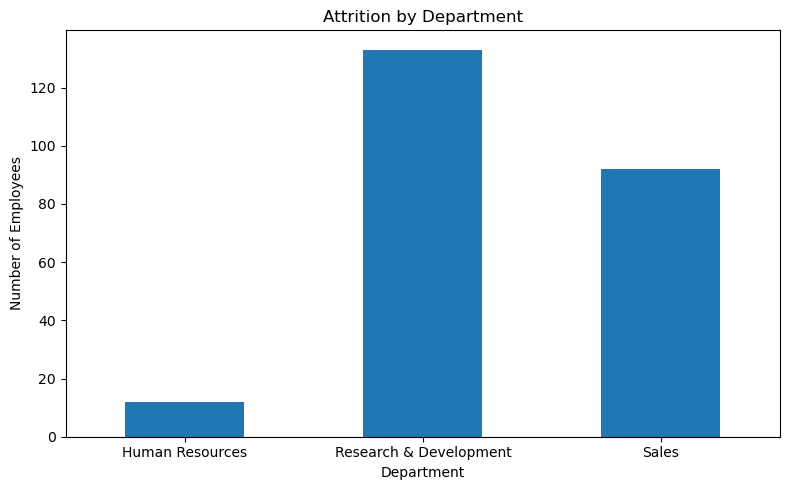

In [39]:
department_attrition_count = hr_clean.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
)

department_attrition_count.plot(
    kind='bar',
    figsize=(8, 5),
    title='Attrition by Department'
)

plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

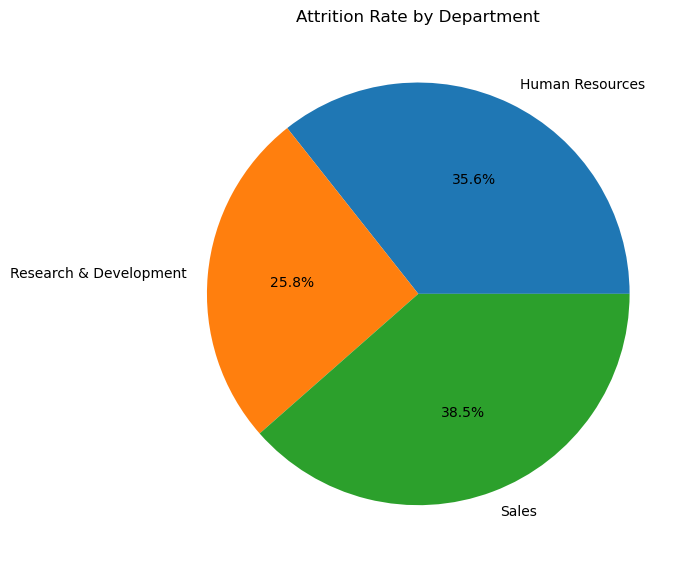

In [40]:
department_attrition.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7),
    title='Attrition Rate by Department'
)

plt.ylabel('')
plt.tight_layout()
plt.show()

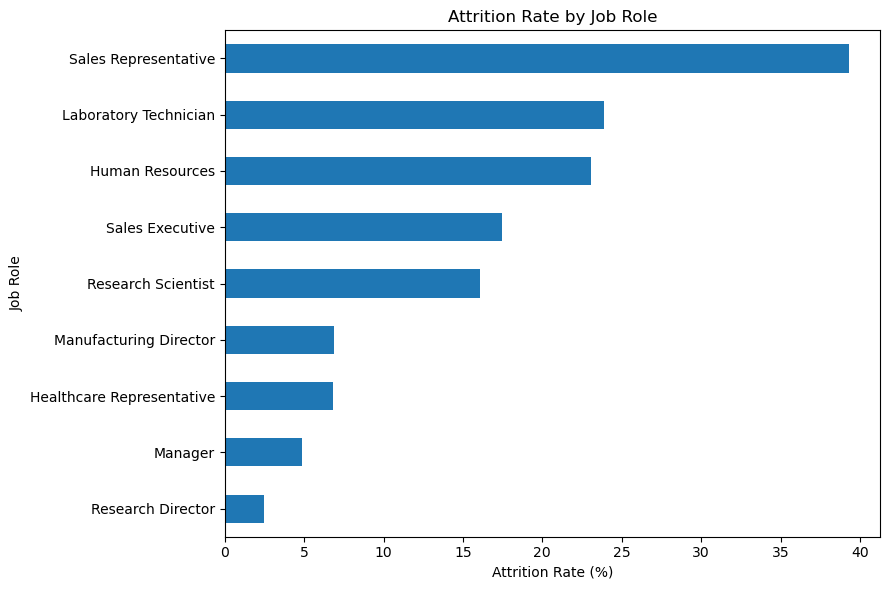

In [41]:
role_attrition.sort_values().plot(
    kind='barh',
    figsize=(9, 6),
    title='Attrition Rate by Job Role'
)

plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

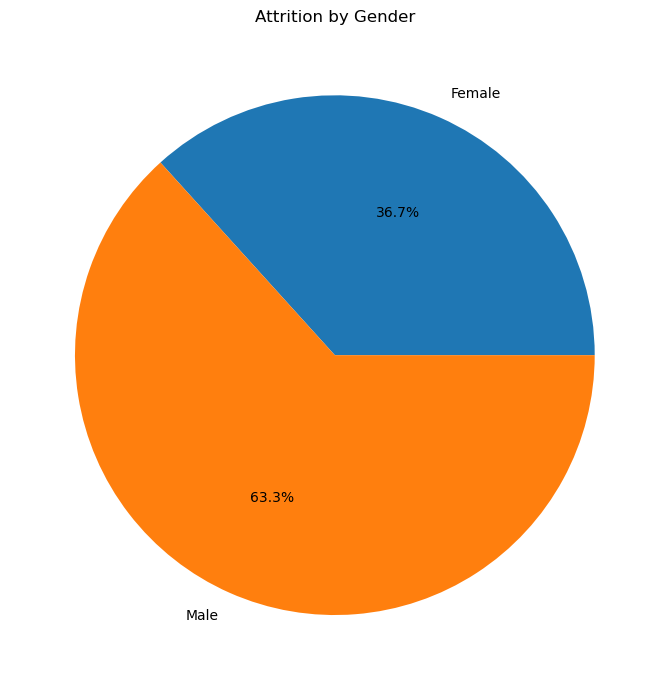

In [42]:
gender_attrition = hr_clean.groupby('Gender')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
)

gender_attrition.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7),
    title='Attrition by Gender'
)

plt.ylabel('')
plt.tight_layout()
plt.show()

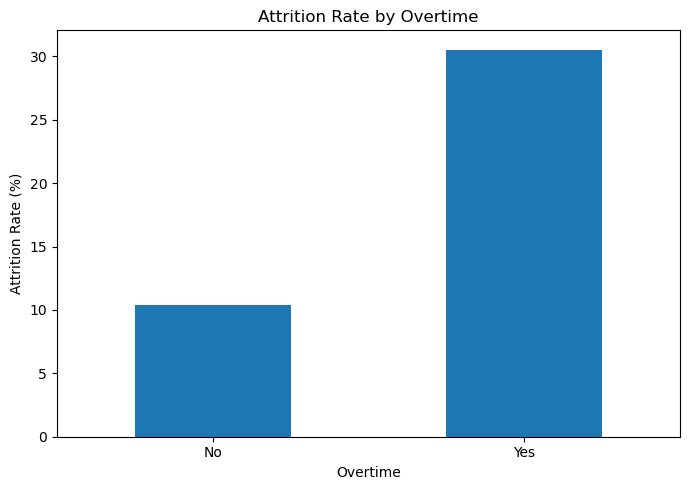

In [43]:
overtime_attrition.plot(
    kind='bar',
    figsize=(7, 5),
    title='Attrition Rate by Overtime'
)

plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

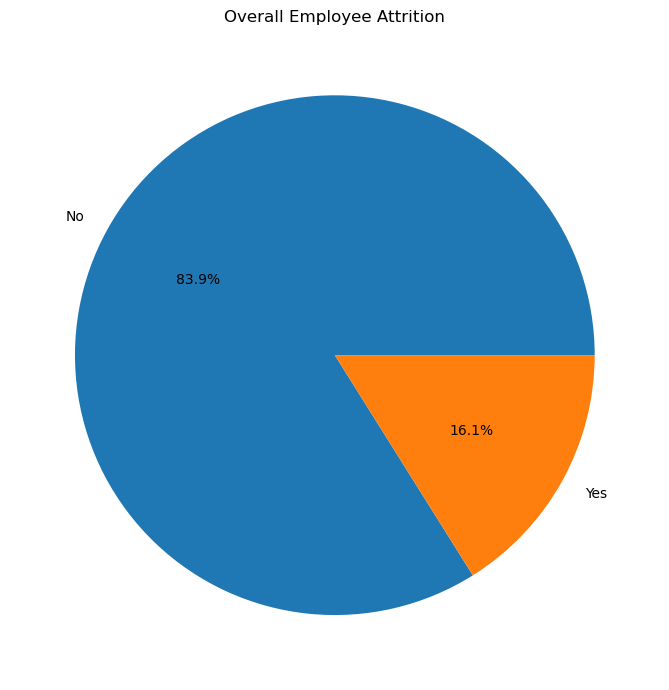

In [46]:
overall_attrition = hr_clean['Attrition'].value_counts()

overall_attrition.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7),
    title='Overall Employee Attrition'
)

plt.ylabel('')
plt.tight_layout()
plt.show()

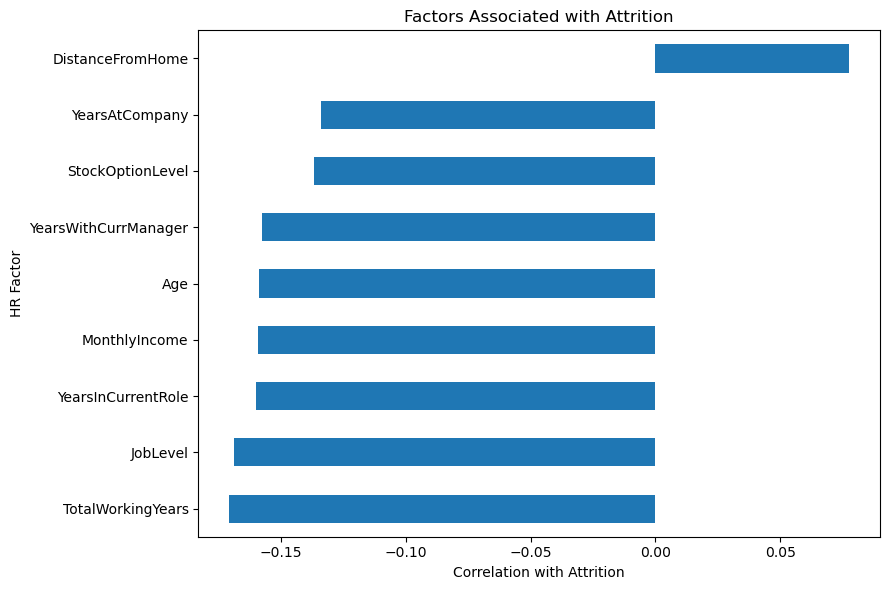

In [47]:
key_correlations = correlation[
    ['TotalWorkingYears',
     'JobLevel',
     'YearsInCurrentRole',
     'MonthlyIncome',
     'Age',
     'YearsWithCurrManager',
     'StockOptionLevel',
     'YearsAtCompany',
     'DistanceFromHome']
]

key_correlations.sort_values().plot(
    kind='barh',
    figsize=(9, 6),
    title='Factors Associated with Attrition'
)

plt.xlabel('Correlation with Attrition')
plt.ylabel('HR Factor')
plt.tight_layout()
plt.show()

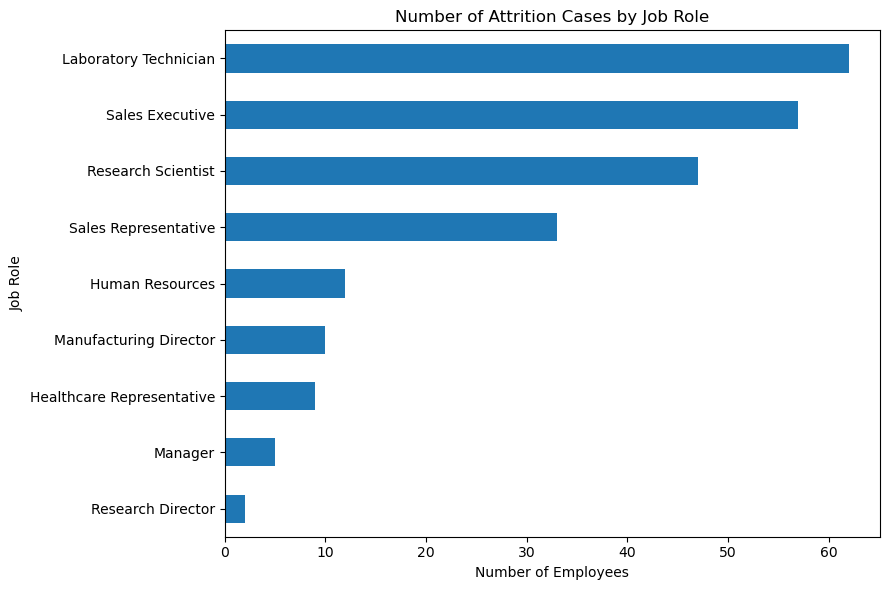

In [48]:
role_attrition_count = hr_clean.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum()
).sort_values()

role_attrition_count.plot(
    kind='barh',
    figsize=(9, 6),
    title='Number of Attrition Cases by Job Role'
)

plt.xlabel('Number of Employees')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

## 8. Exporting the Cleaned Dataset

The cleaned HR dataset is exported as a CSV file for further analysis and dashboard creation in Power BI.

In [38]:
hr_clean.to_csv("HR Analytics Cleaned.csv", index=False)

THANKYOU!!!!!